# **Optimizacion de Portafolios** - Notebook 3

## **Resumen de este notebook**

Este Notebook desarrolla el proceso de optimización de cartera utilizando la Teoría Moderna de Portafolios.

A partir del universo de inversión seleccionado, los rendimientos históricos de los activos se transforman en los datos estadísticos necesarios para la optimización, incluyendo los rendimientos esperados y la matriz de covarianza.

Estos datos se utilizan para construir la Frontera Eficiente e identificar las asignaciones óptimas de cartera bajo diferentes objetivos de inversión.

Las carteras resultantes servirán de base para el análisis de riesgo integral que se realizará en el siguiente cuaderno.

### **Objetivo de negocio**

Determinar la asignación óptima de capital en el universo de inversión seleccionado para maximizar la rentabilidad ajustada al riesgo, manteniendo un nivel adecuado de diversificación de la cartera.

El objetivo es proporcionar una asignación de inversión basada en evidencia que permita la apreciación del capital a largo plazo.

Cliente:

- Capital inicial: **USD 10.000**
- Horizonte de inversión: **10 años**
- Reinvierte todas las ganancias (interés compuesto)
- Perfil:
    - tolerancia al riesgo alta
    - busca crecimiento del capital
    - acepta volatilidad elevada
- Quiere un portafolio de activos financieros.
- Espera una recomendación basada en datos.

### **Objetivo analitico**

Estimar los datos estadísticos necesarios para la optimización de la cartera y aplicar la Teoría Moderna de Portafolio para identificar asignaciones de cartera eficientes bajo diferentes criterios de optimización.

El proceso de optimización incluye la estimación de los rendimientos esperados, el riesgo de la cartera y las ponderaciones de activos eficientes.

### **Preguntas de negocio a contestar en este notebook**

Este notebook tiene como objetivo responder las siguientes preguntas:

- ¿Cuál es la rentabilidad esperada de cada activo?

- ¿Cuánto riesgo aporta cada activo?

- ¿Cómo interactúan los activos entre sí a través de su estructura de covarianza?

- ¿Qué cartera ofrece la mayor rentabilidad esperada para un nivel de riesgo determinado?

- ¿Qué asignación maximiza el ratio de Sharpe?

- ¿Qué asignación minimiza la volatilidad de la cartera?

- ¿Cómo se debe distribuir el capital en el universo de inversión?

### **Entregables de este notebook**

Al finalizar este Notebook, se entregarán los siguientes elementos:

- Matriz de rendimiento diario
- Estimaciones de rendimiento esperado
- Matriz de covarianza
- Frontera eficiente
- Simulación de cartera Monte Carlo
- Cartera de máxima Sharpe
- Cartera de mínima volatilidad
- Asignación óptima de cartera
- Ponderaciones de la cartera
- Resumen de optimización

## **Importacion de librerias**

In [98]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pypfopt import EfficientFrontier
from pypfopt import expected_returns
from pypfopt import risk_models
from pypfopt import plotting

from src.data_loader import load_dataset

In [100]:
RAW_DATA_PATH = "../data/raw/"
PROCESSED_DATA_PATH = "../data/processed/"
REPORTS_PATH = "../reports/"

In [101]:
TRADING_DAYS = 252
RISK_FREE_RATE = 0.04
INITIAL_CAPITAL = 10_000

## **Cargar datos**

In [102]:
primary_universe = load_dataset(
    PROCESSED_DATA_PATH + "primary_universe.parquet"
)

sensitivity_universe = load_dataset(
    PROCESSED_DATA_PATH + "sensitivity_universe.parquet"
)

close_prices = load_dataset(
    PROCESSED_DATA_PATH + "close_prices.parquet"
)

In [103]:
sensitivity_universe

,ticker,asset_name,asset_class,sector
0,NVDA,Nvidia,Equity - Large Cap,Semiconductors
1,AAPL,Apple,Equity - Large Cap,Technology Hardware
2,GOOGL,Alphabet (Google),Equity - Large Cap,Internet & Media
3,AVGO,Broadcom,Equity - Large Cap,Semiconductors
4,BRK-B,Berkshire Hathaway,Equity - Large Cap,Diversified Holdings
5,MU,Micron Technology,Equity - Large Cap,Semiconductors
6,LLY,Eli Lilly,Equity - Large Cap,Pharmaceuticals
7,GE,General Electric,Equity - Large Cap,Industrials
8,NEE,NextEra Energy,Equity - Growth,Renewable Energy
9,BEP,Brookfield Renewable Partners,Equity - Growth,Renewable Energy


In [104]:
print(f"Primary Universe: {primary_universe.shape}")
print(f"Sensitivity Universe: {sensitivity_universe.shape}")
print(f"Close Prices: {close_prices.shape}")

Primary Universe: (31, 4)
Sensitivity Universe: (32, 4)
Close Prices: (1258, 32)


In [105]:
display(primary_universe.head())

display(sensitivity_universe.head())

display(close_prices.head())

,ticker,asset_name,asset_class,sector
0,NVDA,Nvidia,Equity - Large Cap,Semiconductors
1,AAPL,Apple,Equity - Large Cap,Technology Hardware
2,GOOGL,Alphabet (Google),Equity - Large Cap,Internet & Media
3,AVGO,Broadcom,Equity - Large Cap,Semiconductors
4,BRK-B,Berkshire Hathaway,Equity - Large Cap,Diversified Holdings


,ticker,asset_name,asset_class,sector
0,NVDA,Nvidia,Equity - Large Cap,Semiconductors
1,AAPL,Apple,Equity - Large Cap,Technology Hardware
2,GOOGL,Alphabet (Google),Equity - Large Cap,Internet & Media
3,AVGO,Broadcom,Equity - Large Cap,Semiconductors
4,BRK-B,Berkshire Hathaway,Equity - Large Cap,Diversified Holdings


Ticker,AAPL,AVGO,BEP,BRK-B,CC=F,CHWY,CL=F,COUR,DE,DUOL,...,LLY,MS,MU,NEE,NVDA,PFE,PSO,RVLV,UPS,W
Date,,,,,,,,,,,,,,,,,,,,,
2021-06-01,121.142166,42.302994,31.872854,289.839996,2431.0,73.529999,67.720001,38.529999,340.536041,NaN,...,189.276016,78.408325,82.057785,63.236546,16.204721,29.284317,10.627219,58.740002,170.162460,318.000000
2021-06-02,121.902466,42.792595,32.009960,290.019989,2426.0,77.519997,68.830002,39.959999,333.157776,NaN,...,189.953262,78.961647,82.243073,63.753876,16.716583,29.504908,10.494267,59.110001,169.061493,332.890015
2021-06-03,120.420868,41.985939,31.453487,291.970001,2415.0,75.129997,68.809998,39.599998,335.212463,NaN,...,193.358780,79.463867,79.990501,63.455753,16.907381,29.641827,10.520859,58.459999,169.117371,325.579987
2021-06-04,122.711533,42.907314,31.598652,292.519989,2409.0,75.209999,69.620003,39.650002,333.092346,NaN,...,192.710129,79.983124,81.677490,63.429436,17.513647,29.778732,10.644947,56.509998,168.040298,321.029999
2021-06-07,122.721275,41.893787,31.276043,289.459991,2350.0,78.559998,69.230003,41.669998,331.962189,NaN,...,212.265411,79.344681,81.950523,63.543430,17.554245,29.657030,10.742442,54.450001,169.867279,327.950012


### **Preparar los datos de entrada para la optimización**

### Matriz de precios
La matriz de precios históricos se filtra para incluir únicamente los activos seleccionados para el universo de inversión principal. Esto garantiza que todas las estimaciones posteriores de rentabilidad y riesgo se calculen exclusivamente a partir de valores elegibles.

In [106]:
selected_assets = primary_universe["ticker"].tolist()

price_matrix = close_prices[selected_assets]

In [107]:
print(f"Price Matrix Shape: {price_matrix.shape}")

display(price_matrix.head())

Price Matrix Shape: (1258, 31)


Ticker,NVDA,AAPL,GOOGL,AVGO,BRK-B,MU,LLY,GE,NEE,BEP,...,JPM,KO,MS,PFE,DE,GC=F,CL=F,KC=F,CC=F,IEF
Date,,,,,,,,,,,,,,,,,,,,,
2021-06-01,16.204721,121.142166,118.012558,42.302994,289.839996,82.057785,189.276016,68.806023,63.236546,31.872854,...,145.684082,47.322876,78.408325,29.284317,340.536041,1902.900024,67.720001,161.050003,2431.0,98.797569
2021-06-02,16.716583,121.902466,117.487709,42.792595,290.019989,82.243073,189.953262,68.514267,63.753876,32.009960,...,145.692841,47.511208,78.961647,29.504908,333.157776,1907.500000,68.830002,161.149994,2426.0,98.909912
2021-06-03,16.907381,120.420868,116.347321,41.985939,291.970001,79.990501,193.358780,68.514267,63.455753,31.453487,...,145.789368,47.631054,79.463867,29.641827,335.212463,1871.199951,68.809998,157.600006,2415.0,98.659233
2021-06-04,17.513647,122.711533,118.626610,42.907314,292.519989,81.677490,192.710129,67.882133,63.429436,31.598652,...,146.026230,48.144691,79.983124,29.778732,333.092346,1889.800049,69.620003,161.649994,2409.0,99.203789
2021-06-07,17.554245,122.721275,119.059280,41.893787,289.459991,81.950523,212.265411,67.638992,63.543430,31.276043,...,145.341888,47.973476,79.344681,29.657030,331.962189,1896.800049,69.230003,160.149994,2350.0,99.126007


### Calcular retornos diarios

In [108]:
daily_returns = price_matrix.pct_change().dropna()
daily_returns

Ticker,NVDA,AAPL,GOOGL,AVGO,BRK-B,MU,LLY,GE,NEE,BEP,...,JPM,KO,MS,PFE,DE,GC=F,CL=F,KC=F,CC=F,IEF
Date,,,,,,,,,,,,,,,,,,,,,
2021-07-29,0.008153,0.004552,-0.002325,0.013524,0.005969,0.020252,-0.004787,0.012186,0.003982,0.005056,...,0.008569,0.005463,0.009542,-0.006270,0.017649,0.017616,0.016991,-0.019706,0.003296,-0.003058
2021-07-30,-0.008290,0.001510,-0.007740,0.002665,-0.005255,0.006487,-0.007459,-0.025583,-0.003327,-0.011066,...,-0.007974,-0.000351,-0.003116,0.000467,0.004975,-0.010157,0.004482,-0.086260,-0.028337,0.002812
2021-08-02,0.012873,-0.002331,0.000950,-0.001483,-0.000539,0.000774,0.012731,-0.028958,0.011682,-0.013734,...,-0.004019,-0.002630,0.002605,0.026863,-0.015598,0.003034,-0.036376,-0.037594,-0.001268,0.004386
2021-08-03,0.003291,0.012644,0.005750,0.004353,0.013159,0.041474,0.038078,0.024453,0.007740,0.000516,...,0.011378,0.000703,0.003845,0.039126,0.027841,-0.004400,-0.009823,0.011863,0.026661,0.000254
2021-08-04,0.023164,-0.002782,-0.003720,0.002075,-0.010717,0.013851,0.025314,-0.001455,0.005666,-0.012113,...,-0.010792,-0.014406,-0.003209,-0.010726,-0.014186,0.000221,-0.034155,0.004575,-0.013603,-0.000254
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-22,-0.019042,0.012558,-0.012098,-0.001037,0.013334,-0.014565,0.022416,0.003579,-0.012710,0.004809,...,0.011155,0.003819,0.002593,-0.001927,-0.004140,-0.004141,0.002595,-0.003840,0.007698,0.000853
2026-05-26,-0.002183,-0.001587,0.015432,0.019003,-0.005675,0.192916,-0.000244,0.038469,-0.010164,0.039977,...,0.001175,-0.012519,0.003631,-0.001930,-0.000057,-0.004557,-0.028054,0.006058,0.098261,0.004261
2026-05-27,-0.010518,0.008173,-0.000129,-0.000356,-0.007651,0.036311,0.017075,0.008649,0.000000,-0.011370,...,-0.024320,0.014417,-0.000743,0.013926,0.000510,-0.011754,-0.055490,-0.015146,-0.006956,0.000424


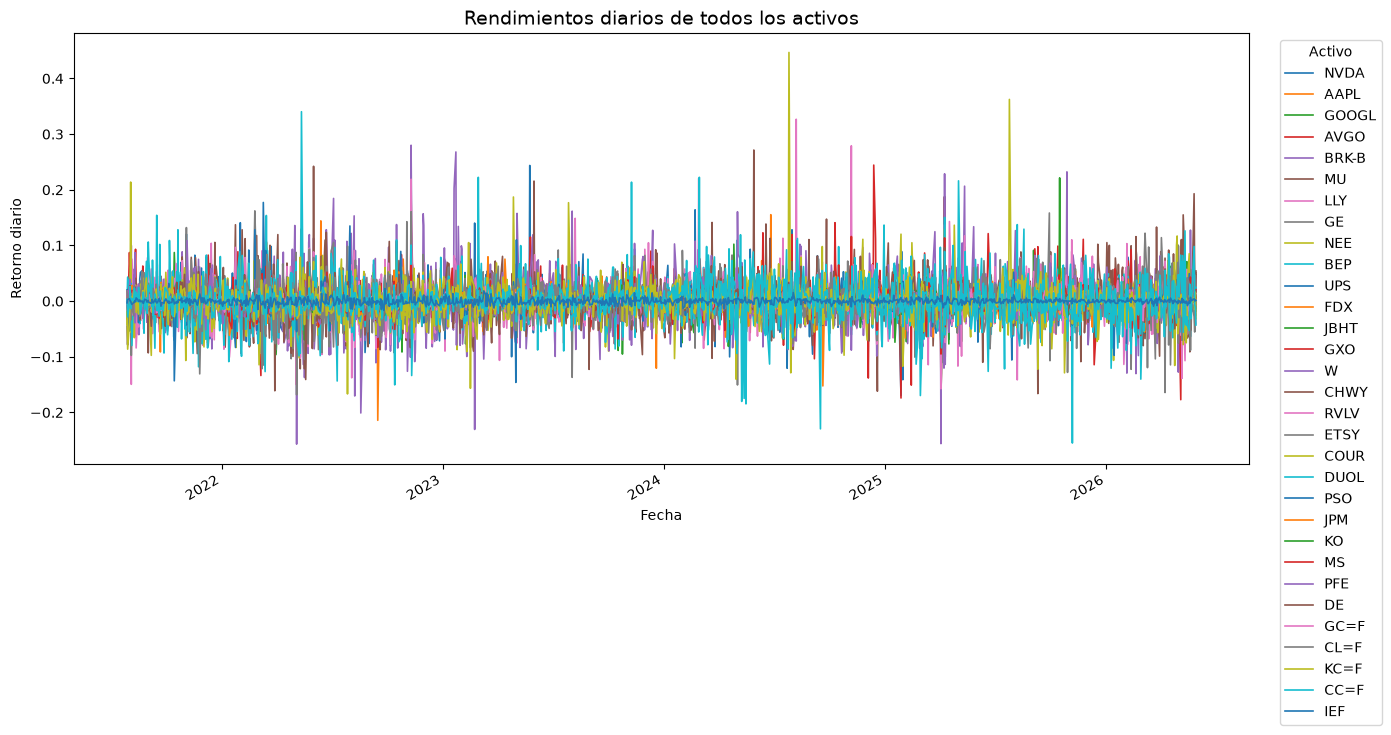

In [109]:
ax = daily_returns.plot.line(figsize=(14, 7), linewidth=1.2)
ax.set_title('Rendimientos diarios de todos los activos', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Retorno diario')
ax.legend(title='Activo', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Estimar los rendimientos esperados

In [110]:
comparison_returns = pd.DataFrame({
    "mean_historical": expected_returns.mean_historical_return(price_matrix),
    "ema_historical": expected_returns.ema_historical_return(price_matrix, span=500),
    "capm": expected_returns.capm_return(price_matrix)
})

comparison_returns.sort_values("mean_historical", ascending=False)

c:\Users\nicol\miniconda3\envs\portfolio_opt\Lib\site-packages\pypfopt\expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
c:\Users\nicol\miniconda3\envs\portfolio_opt\Lib\site-packages\pypfopt\expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
c:\Users\nicol\miniconda3\envs\portfolio_opt\Lib\site-packages\pypfopt\expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(


,mean_historical,ema_historical,capm
Ticker,,,
NVDA,0.696138,0.725586,0.301474
MU,0.652355,5.735818,0.274373
AVGO,0.613274,1.083732,0.223851
LLY,0.422189,0.459286,0.076512
GE,0.364472,0.527557,0.158651
GOOGL,0.275509,0.789834,0.171004
MS,0.225986,0.604215,0.174688
AAPL,0.221847,0.409351,0.164270
GC=F,0.190557,0.350837,0.020540


In [111]:
expected_returns_vector = expected_returns.capm_return(
    price_matrix
)

c:\Users\nicol\miniconda3\envs\portfolio_opt\Lib\site-packages\pypfopt\expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(


In [112]:
display(expected_returns_vector.sort_values(ascending=False))

Ticker
W        0.498878
RVLV     0.336077
CHWY     0.308968
DUOL     0.301984
ETSY     0.301655
NVDA     0.301474
MU       0.274373
COUR     0.255232
GXO      0.254948
AVGO     0.223851
MS       0.174688
GOOGL    0.171004
AAPL     0.164270
JBHT     0.163360
FDX      0.162447
GE       0.158651
UPS      0.138563
JPM      0.127395
DE       0.124556
BEP      0.123608
NEE      0.085356
BRK-B    0.083401
PSO      0.081924
LLY      0.076512
CC=F     0.072251
PFE      0.058747
KC=F     0.052695
CL=F     0.040140
KO       0.036126
GC=F     0.020540
IEF      0.008442
Name: mkt, dtype: float64

### Estimar la matriz de covarianza

In [113]:
covariance_matrix = risk_models.sample_cov(
    price_matrix
)

In [114]:
covariance_matrix.shape

(31, 31)

In [115]:
covariance_matrix

Ticker,NVDA,AAPL,GOOGL,AVGO,BRK-B,MU,LLY,GE,NEE,BEP,...,JPM,KO,MS,PFE,DE,GC=F,CL=F,KC=F,CC=F,IEF
Ticker,,,,,,,,,,,,,,,,,,,,,
NVDA,0.266816,0.070349,0.082300,0.139631,0.021013,0.149700,0.029036,0.064942,0.014808,0.042372,...,0.041323,-0.000003,0.062042,0.004121,0.031308,0.002911,0.007544,0.001639,0.021711,0.000550
AAPL,0.070349,0.075217,0.047930,0.051955,0.020769,0.054859,0.018154,0.031597,0.018089,0.021967,...,0.024992,0.011711,0.034278,0.013638,0.022845,0.000742,0.003361,0.005348,0.009850,0.001227
GOOGL,0.082300,0.047930,0.097754,0.059908,0.017282,0.067331,0.018566,0.033034,0.014730,0.022494,...,0.024923,0.006249,0.034742,0.009338,0.017929,0.004543,0.002388,0.007485,0.010083,0.001342
AVGO,0.139631,0.051955,0.059908,0.182994,0.015056,0.128132,0.021078,0.050256,0.012360,0.032956,...,0.033197,-0.000307,0.050327,0.006925,0.025484,0.004440,0.008760,0.008288,0.020275,0.000658
BRK-B,0.021013,0.020769,0.017282,0.015056,0.029220,0.018241,0.013246,0.022211,0.013837,0.010934,...,0.025803,0.011715,0.025673,0.013279,0.020279,0.000579,0.007087,0.004733,0.003292,0.000069
MU,0.149700,0.054859,0.067331,0.128132,0.018241,0.273573,0.020664,0.064754,0.013769,0.038953,...,0.038593,0.000283,0.063440,0.008945,0.032696,0.010800,0.002625,0.011861,0.028723,-0.001033
LLY,0.029036,0.018154,0.018566,0.021078,0.013246,0.020664,0.107627,0.020626,0.015783,0.011194,...,0.012971,0.009874,0.012735,0.023164,0.008167,0.001721,-0.004915,0.002422,0.001308,0.001652
GE,0.064942,0.031597,0.033034,0.050256,0.022211,0.064754,0.020626,0.096034,0.016180,0.026480,...,0.038377,0.008743,0.044410,0.007987,0.032949,0.003621,0.001544,0.008803,0.009209,-0.001101
NEE,0.014808,0.018089,0.014730,0.012360,0.013837,0.013769,0.015783,0.016180,0.071674,0.036583,...,0.010321,0.017425,0.014637,0.014904,0.017090,0.007536,0.003988,0.004246,0.000557,0.004967


### Matriz de correlacion

In [116]:
correlation_matrix = daily_returns.corr()
correlation_matrix

Ticker,NVDA,AAPL,GOOGL,AVGO,BRK-B,MU,LLY,GE,NEE,BEP,...,JPM,KO,MS,PFE,DE,GC=F,CL=F,KC=F,CC=F,IEF
Ticker,,,,,,,,,,,,,,,,,,,,,
NVDA,1.000000,0.502442,0.513589,0.633403,0.245347,0.557212,0.175193,0.420278,0.110037,0.264097,...,0.334055,0.000096,0.429059,0.032048,0.212041,0.036512,0.037744,0.011679,0.089507,0.012894
AAPL,0.502442,1.000000,0.559942,0.444147,0.447622,0.386157,0.208821,0.378009,0.246822,0.260112,...,0.377199,0.263796,0.442873,0.196480,0.286881,0.013520,0.028229,0.049389,0.074336,0.059975
GOOGL,0.513589,0.559942,1.000000,0.448170,0.327795,0.412667,0.179817,0.345695,0.175075,0.231614,...,0.328875,0.120934,0.393043,0.112279,0.196203,0.079782,0.015341,0.062673,0.065350,0.058129
AVGO,0.633403,0.444147,0.448170,1.000000,0.207484,0.572755,0.155698,0.384243,0.109134,0.247751,...,0.319235,-0.008160,0.415099,0.062981,0.204991,0.057178,0.050032,0.053188,0.097720,0.021235
BRK-B,0.245347,0.447622,0.327795,0.207484,1.000000,0.205045,0.250306,0.409695,0.306884,0.207945,...,0.612776,0.427525,0.518354,0.307284,0.399717,0.012405,0.096303,0.073733,0.037399,0.015512
MU,0.557212,0.386157,0.412667,0.572755,0.205045,1.000000,0.122268,0.403116,0.100720,0.242009,...,0.301800,-0.001276,0.426633,0.068299,0.213887,0.112944,0.012140,0.061680,0.113697,-0.022213
LLY,0.175193,0.208821,0.179817,0.155698,0.250306,0.122268,1.000000,0.209655,0.182784,0.117952,...,0.169967,0.190163,0.141357,0.277142,0.090696,0.030540,-0.037825,0.026023,0.009956,0.066757
GE,0.420278,0.378009,0.345695,0.384243,0.409695,0.403116,0.209655,1.000000,0.202738,0.279012,...,0.499129,0.173162,0.493190,0.098028,0.354685,0.059109,-0.000125,0.069998,0.058119,-0.035302
NEE,0.110037,0.246822,0.175075,0.109134,0.306884,0.100720,0.182784,0.202738,1.000000,0.444935,...,0.162523,0.407418,0.198625,0.215890,0.224488,0.157286,0.038752,0.044879,0.004696,0.241544


## **Simulacion de monte carlo**
Subsecciones:
- Generar portafolios
- Calcular las metricas del portafolio
- Identificar candidatos eficientes

### Generar Portafolios

In [117]:
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

In [118]:
# Montecarlo Simulation Parameters

N_PORTFOLIOS = 100_000
N_ASSETS = len(price_matrix.columns)

In [119]:
# Generate Random Portfolio Weights

portfolio_weights = []

for _ in range(N_PORTFOLIOS):

    weights = np.random.random(N_ASSETS)
    weights /= weights.sum()

    portfolio_weights.append(weights)

portfolio_weights = np.array(portfolio_weights)

In [120]:
print(portfolio_weights.shape)

(100000, 31)


In [121]:
portfolio_weights[0].sum()

np.float64(1.0)

In [122]:
portfolio_weights[:5].sum(axis=1)

array([1., 1., 1., 1., 1.])

### Calcular las metricas del portafolio

Expected Annual Return
Annual Volatility
Sharpe Ratio

In [123]:
portfolio_returns = []
portfolio_volatility = []
portfolio_sharpe = []

for weights in portfolio_weights:

    # Expected annual return
    expected_return = np.dot(weights, expected_returns_vector)

    # Annual volatility
    volatility = np.sqrt(
        np.dot(weights.T, np.dot(covariance_matrix, weights))
    )

    # Sharpe Ratio
    sharpe = (expected_return - RISK_FREE_RATE) / volatility

    portfolio_returns.append(expected_return)
    portfolio_volatility.append(volatility)
    portfolio_sharpe.append(sharpe)

In [124]:
portfolio_returns = np.array(portfolio_returns)
portfolio_volatility = np.array(portfolio_volatility)
portfolio_sharpe = np.array(portfolio_sharpe)

In [125]:
simulation_results = pd.DataFrame({
    "expected_return": portfolio_returns,
    "volatility": portfolio_volatility,
    "sharpe_ratio": portfolio_sharpe,
})

In [126]:
simulation_results.head()

,expected_return,volatility,sharpe_ratio
0,0.156400,0.177992,0.653959
1,0.173569,0.197669,0.675720
2,0.175063,0.199265,0.677806
3,0.160243,0.183339,0.655852
4,0.176896,0.201381,0.679785


### Identificar candidatos eficientes

In [127]:
max_sharpe_idx = simulation_results["sharpe_ratio"].idxmax()
min_volatility_idx = simulation_results["volatility"].idxmin()

In [128]:
max_sharpe_portfolio = simulation_results.loc[max_sharpe_idx]

min_volatility_portfolio = simulation_results.loc[min_volatility_idx]

In [129]:
print("Maximum Sharpe Portfolio")
display(max_sharpe_portfolio)

print("Minimum Volatility Portfolio")
display(min_volatility_portfolio)

Maximum Sharpe Portfolio


expected_return    0.222001
volatility         0.254582
sharpe_ratio       0.714901
Name: 71593, dtype: float64

Minimum Volatility Portfolio


expected_return    0.114901
volatility         0.139039
sharpe_ratio       0.538706
Name: 85379, dtype: float64

## **Optimizacion Mean-Variance** - tradicional
subsecciones:
- Frontera eficiente
- Portafolio Max Sharpe
- Portafolio Minima varianza
- Target Return Portfolio (opcional, si queremos explorar un retorno objetivo específico)

En esta sección se aplica el modelo clásico de optimización de media-varianza propuesto por Harry Markowitz. El objetivo es construir portafolios que maximicen el rendimiento ajustado por riesgo (Sharpe Ratio) o minimicen la volatilidad utilizando únicamente las estimaciones de retornos esperados y la matriz de covarianzas.

Es importante destacar que, en esta etapa, no se incorporan restricciones adicionales de diversificación, como límites máximos o mínimos por activo. Por ello, la solución obtenida representa el óptimo matemático del problema, aunque no necesariamente el más adecuado desde una perspectiva práctica de gestión de inversiones.

### Portfolio Maximo Sharpe

In [130]:
# Maximum Sharpe Portfolio

ef_max_sharpe = EfficientFrontier(
    expected_returns_vector,
    covariance_matrix
)

ef_max_sharpe.max_sharpe(
    risk_free_rate=RISK_FREE_RATE
)

max_sharpe_weights = ef_max_sharpe.clean_weights()

### Portfolio Minimum Volatility

In [131]:
# Minimum Volatility Portfolio

ef_min_vol = EfficientFrontier(
    expected_returns_vector,
    covariance_matrix
)

ef_min_vol.min_volatility()

min_volatility_weights = ef_min_vol.clean_weights()

### Portfolios performance

In [132]:
max_sharpe_performance = ef_max_sharpe.portfolio_performance(
    risk_free_rate=RISK_FREE_RATE,
    verbose=False
)

In [133]:
min_volatility_performance = ef_min_vol.portfolio_performance(
    risk_free_rate=RISK_FREE_RATE,
    verbose=False
)

In [134]:
portfolio_summary = pd.DataFrame({
    "Portfolio": [
        "Maximum Sharpe",
        "Minimum Volatility"
    ],
    "Expected Return": [
        max_sharpe_performance[0],
        min_volatility_performance[0]
    ],
    "Volatility": [
        max_sharpe_performance[1],
        min_volatility_performance[1]
    ],
    "Sharpe Ratio": [
        max_sharpe_performance[2],
        min_volatility_performance[2]
    ]
})

In [135]:
portfolio_summary

,Portfolio,Expected Return,Volatility,Sharpe Ratio
0,Maximum Sharpe,0.276111,0.322336,0.732500
1,Minimum Volatility,0.025798,0.064341,-0.220729


### Portfolio Allocation

In [136]:
max_sharpe_allocation = (
    pd.DataFrame.from_dict(
        max_sharpe_weights,
        orient="index",
        columns=["weight"]
    )
    .reset_index(names="ticker")
)

In [137]:
max_sharpe_allocation = (
    max_sharpe_allocation
    .query("weight > 0")
    .sort_values("weight", ascending=False)
)

In [138]:
max_sharpe_weights_df = (
    pd.DataFrame.from_dict(
        max_sharpe_weights,
        orient="index",
        columns=["weight"]
    )
    .reset_index(names="ticker")
)

max_sharpe_weights_df = (
    max_sharpe_weights_df
    .query("weight > 0")
    .sort_values("weight", ascending=False)
)

In [139]:
min_volatility_weights_df = (
    pd.DataFrame.from_dict(
        min_volatility_weights,
        orient="index",
        columns=["weight"]
    )
    .reset_index(names="ticker")
)

min_volatility_weights_df = (
    min_volatility_weights_df
    .query("weight > 0")
    .sort_values("weight", ascending=False)
)

In [140]:
display(
    max_sharpe_weights_df.style.format({
        "weight": "{:.2%}"
    })
)

,ticker,weight
13,GXO,10.88%
14,W,10.47%
0,NVDA,9.00%
5,MU,7.92%
16,RVLV,7.66%
23,MS,7.46%
19,DUOL,6.44%
15,CHWY,6.17%
17,ETSY,6.15%
18,COUR,5.82%


In [141]:
display(
    min_volatility_weights_df.style.format({
        "weight": "{:.2%}"
    })
)

,ticker,weight
30,IEF,70.88%
22,KO,6.39%
21,JPM,4.84%
27,CL=F,4.02%
4,BRK-B,3.57%
26,GC=F,2.76%
28,KC=F,1.92%
29,CC=F,1.54%
20,PSO,1.43%
24,PFE,0.75%


In [142]:
portfolio_summary

,Portfolio,Expected Return,Volatility,Sharpe Ratio
0,Maximum Sharpe,0.276111,0.322336,0.732500
1,Minimum Volatility,0.025798,0.064341,-0.220729


## **Optimizacion mean variance con restricciones**

subsecciones
- Restricciones
- Max sharpe con restricciones
- Min volatilidad con restricciones
- Comparacion del performance

La optimización clásica de Markowitz proporciona la solución matemáticamente óptima bajo el criterio de media-varianza. Sin embargo, al no incorporar restricciones adicionales, es común obtener carteras altamente concentradas en un pequeño número de activos, lo que puede dificultar su implementación en un contexto real de gestión de inversiones.

En esta sección se incorporan restricciones de asignación por activo con el objetivo de construir una cartera más diversificada y representativa. Estas restricciones limitan el peso mínimo y máximo que puede recibir cada activo, permitiendo comparar el desempeño del portafolio clásico con una alternativa más realista desde el punto de vista operativo.

Posteriormente, se analizarán las diferencias entre ambos enfoques en términos de rendimiento esperado, riesgo, diversificación y distribución de pesos.

### Definicion de restricciones

In [143]:
MIN_WEIGHT = 0.00
MAX_WEIGHT = 0.15

### Portfolio Max Sharpe con restricciones

In [144]:
ef_max_sharpe_constrained = EfficientFrontier(
    expected_returns_vector,
    covariance_matrix,
    weight_bounds=(MIN_WEIGHT, MAX_WEIGHT)
)

ef_max_sharpe_constrained.max_sharpe(
    risk_free_rate=RISK_FREE_RATE
)

max_sharpe_weights_constrained = (
    ef_max_sharpe_constrained.clean_weights()
)

### Portfolio Minima Volatilidad con restricciones

In [145]:
ef_min_volatility_constrained = EfficientFrontier(
    expected_returns_vector,
    covariance_matrix,
    weight_bounds=(MIN_WEIGHT, MAX_WEIGHT)
)

ef_min_volatility_constrained.min_volatility()

min_volatility_weights_constrained = (
    ef_min_volatility_constrained.clean_weights()
)

### Resumen del Desempeño

In [146]:
max_sharpe_performance_constrained = (
    ef_max_sharpe_constrained.portfolio_performance(
        risk_free_rate=RISK_FREE_RATE
    )
)

min_volatility_performance_constrained = (
    ef_min_volatility_constrained.portfolio_performance(
        risk_free_rate=RISK_FREE_RATE
    )
)

In [147]:
portfolio_summary_constrained = pd.DataFrame(
    {
        "Portfolio": [
            "Maximum Sharpe",
            "Minimum Volatility"
        ],
        "Expected Return": [
            max_sharpe_performance_constrained[0],
            min_volatility_performance_constrained[0]
        ],
        "Volatility": [
            max_sharpe_performance_constrained[1],
            min_volatility_performance_constrained[1]
        ],
        "Sharpe Ratio": [
            max_sharpe_performance_constrained[2],
            min_volatility_performance_constrained[2]
        ]
    }
)

portfolio_summary_constrained

,Portfolio,Expected Return,Volatility,Sharpe Ratio
0,Maximum Sharpe,0.276111,0.322336,0.732500
1,Minimum Volatility,0.055200,0.093174,0.163136


In [148]:
max_sharpe_weights_constrained_df = (
    pd.DataFrame.from_dict(
        max_sharpe_weights_constrained,
        orient="index",
        columns=["weight"]
    )
    .reset_index(names="ticker")
)

max_sharpe_weights_constrained_df = (
    max_sharpe_weights_constrained_df
    .query("weight > 0")
    .sort_values("weight", ascending=False)
)

display(
    max_sharpe_weights_constrained_df.style.format(
        {"weight": "{:.2%}"}
    )
)

,ticker,weight
13,GXO,10.88%
14,W,10.47%
0,NVDA,9.00%
5,MU,7.92%
16,RVLV,7.66%
23,MS,7.46%
19,DUOL,6.44%
15,CHWY,6.17%
17,ETSY,6.15%
18,COUR,5.82%


In [149]:
min_volatility_weights_constrained_df = (
    pd.DataFrame.from_dict(
        min_volatility_weights_constrained,
        orient="index",
        columns=["weight"]
    )
    .reset_index(names="ticker")
)

min_volatility_weights_constrained_df = (
    min_volatility_weights_constrained_df
    .query("weight > 0")
    .sort_values("weight", ascending=False)
)

display(
    min_volatility_weights_constrained_df.style.format(
        {"weight": "{:.2%}"}
    )
)

,ticker,weight
30,IEF,15.00%
4,BRK-B,15.00%
26,GC=F,15.00%
22,KO,15.00%
24,PFE,7.06%
20,PSO,6.01%
27,CL=F,5.62%
28,KC=F,4.50%
29,CC=F,3.72%
6,LLY,3.16%


### Análisis Comparativo de los portafolios

En las secciones anteriores se construyeron dos modelos de optimización de portafolios: un modelo clásico de media-varianza y un modelo con restricciones de asignación por activo. En esta sección se comparan ambos enfoques con el objetivo de evaluar cómo las restricciones influyen en el rendimiento esperado, el riesgo, la diversificación y la distribución de los pesos.

Este análisis permite identificar los compromisos (trade-offs) entre la eficiencia matemática del modelo clásico y la mayor implementabilidad del modelo restringido desde una perspectiva de gestión de inversiones.

In [150]:
comparison_summary = pd.DataFrame({
    "Portfolio": [
        "Maximum Sharpe (Classical)",
        "Minimum Volatility (Classical)",
        "Maximum Sharpe (Constrained)",
        "Minimum Volatility (Constrained)"
    ],
    "Expected Return": [
        portfolio_summary.loc[0, "Expected Return"],
        portfolio_summary.loc[1, "Expected Return"],
        portfolio_summary_constrained.loc[0, "Expected Return"],
        portfolio_summary_constrained.loc[1, "Expected Return"]
    ],
    "Volatility": [
        portfolio_summary.loc[0, "Volatility"],
        portfolio_summary.loc[1, "Volatility"],
        portfolio_summary_constrained.loc[0, "Volatility"],
        portfolio_summary_constrained.loc[1, "Volatility"]
    ],
    "Sharpe Ratio": [
        portfolio_summary.loc[0, "Sharpe Ratio"],
        portfolio_summary.loc[1, "Sharpe Ratio"],
        portfolio_summary_constrained.loc[0, "Sharpe Ratio"],
        portfolio_summary_constrained.loc[1, "Sharpe Ratio"]
    ]
})

comparison_summary

,Portfolio,Expected Return,Volatility,Sharpe Ratio
0,Maximum Sharpe (Classical),0.276111,0.322336,0.732500
1,Minimum Volatility (Classical),0.025798,0.064341,-0.220729
2,Maximum Sharpe (Constrained),0.276111,0.322336,0.732500
3,Minimum Volatility (Constrained),0.055200,0.093174,0.163136


In [151]:
display(max_sharpe_weights_df)

display(max_sharpe_weights_constrained_df)

,ticker,weight
13,GXO,0.10884
14,W,0.10466
0,NVDA,0.08995
5,MU,0.07917
16,RVLV,0.07659
23,MS,0.07461
19,DUOL,0.06439
15,CHWY,0.06166
17,ETSY,0.06151
18,COUR,0.05816


,ticker,weight
13,GXO,0.10884
14,W,0.10466
0,NVDA,0.08995
5,MU,0.07917
16,RVLV,0.07659
23,MS,0.07461
19,DUOL,0.06439
15,CHWY,0.06166
17,ETSY,0.06151
18,COUR,0.05816


In [152]:
display(min_volatility_weights_df)

display(min_volatility_weights_constrained_df)

,ticker,weight
30,IEF,0.70885
22,KO,0.06394
21,JPM,0.04841
27,CL=F,0.04016
4,BRK-B,0.03566
26,GC=F,0.02763
28,KC=F,0.01922
29,CC=F,0.01540
20,PSO,0.01433
24,PFE,0.00750


,ticker,weight
30,IEF,0.15000
4,BRK-B,0.15000
26,GC=F,0.15000
22,KO,0.15000
24,PFE,0.07059
20,PSO,0.06012
27,CL=F,0.05619
28,KC=F,0.04504
29,CC=F,0.03723
6,LLY,0.03155


La incorporación de restricciones modificó la distribución de los pesos del portafolio, reduciendo la concentración en activos individuales y promoviendo una asignación más equilibrada del capital. Si bien estas restricciones pueden disminuir ligeramente la eficiencia matemática del modelo, permiten construir carteras más diversificadas y potencialmente más fáciles de implementar en un contexto real de inversión.

Asimismo, se observa que el número de activos seleccionados varía entre ambos enfoques, reflejando cómo las restricciones alteran el espacio de soluciones disponible para el optimizador.

## **Analisis de sensibilidad**

Los resultados obtenidos mediante modelos de optimización dependen directamente del universo de activos utilizado para construir el portafolio. En la práctica, es común encontrar activos con historiales de precios limitados debido a eventos como ofertas públicas iniciales (IPO), escisiones corporativas o fusiones recientes.

Durante la etapa de preparación de los datos se identificó que **General Electric Vernova (GEV)** presentaba un historial de precios significativamente más corto que el resto de los activos del universo de inversión. Aunque se conservaron únicamente las observaciones disponibles para el período común de análisis, resulta pertinente evaluar si la inclusión de este activo influye de manera significativa en la solución óptima obtenida.

Con este objetivo, se realiza un análisis de sensibilidad comparando dos escenarios:

- **Escenario base:** universo completo de activos, incluyendo General Electric Vernova (GEV).
- **Escenario alternativo:** mismo universo de inversión, excluyendo General Electric Vernova (GEV).

Posteriormente se comparan las métricas de desempeño y la composición de los portafolios óptimos para evaluar la robustez del modelo frente a esta modificación del universo de inversión.

In [153]:
selected_assets = sensitivity_universe["ticker"].tolist()

sensitivity_price_matrix = close_prices[selected_assets]

sensitivity_price_matrix.head()

Ticker,NVDA,AAPL,GOOGL,AVGO,BRK-B,MU,LLY,GE,NEE,BEP,...,KO,MS,PFE,DE,GC=F,CL=F,KC=F,CC=F,IEF,GEV
Date,,,,,,,,,,,,,,,,,,,,,
2021-06-01,16.204721,121.142166,118.012558,42.302994,289.839996,82.057785,189.276016,68.806023,63.236546,31.872854,...,47.322876,78.408325,29.284317,340.536041,1902.900024,67.720001,161.050003,2431.0,98.797569,NaN
2021-06-02,16.716583,121.902466,117.487709,42.792595,290.019989,82.243073,189.953262,68.514267,63.753876,32.009960,...,47.511208,78.961647,29.504908,333.157776,1907.500000,68.830002,161.149994,2426.0,98.909912,NaN
2021-06-03,16.907381,120.420868,116.347321,41.985939,291.970001,79.990501,193.358780,68.514267,63.455753,31.453487,...,47.631054,79.463867,29.641827,335.212463,1871.199951,68.809998,157.600006,2415.0,98.659233,NaN
2021-06-04,17.513647,122.711533,118.626610,42.907314,292.519989,81.677490,192.710129,67.882133,63.429436,31.598652,...,48.144691,79.983124,29.778732,333.092346,1889.800049,69.620003,161.649994,2409.0,99.203789,NaN
2021-06-07,17.554245,122.721275,119.059280,41.893787,289.459991,81.950523,212.265411,67.638992,63.543430,31.276043,...,47.973476,79.344681,29.657030,331.962189,1896.800049,69.230003,160.149994,2350.0,99.126007,NaN


In [154]:
sensitivity_daily_returns = (
    sensitivity_price_matrix
    .pct_change()
    .dropna()
)

sensitivity_daily_returns.head()

Ticker,NVDA,AAPL,GOOGL,AVGO,BRK-B,MU,LLY,GE,NEE,BEP,...,KO,MS,PFE,DE,GC=F,CL=F,KC=F,CC=F,IEF,GEV
Date,,,,,,,,,,,,,,,,,,,,,
2024-03-28,0.001175,-0.010559,0.000398,0.005066,0.008611,-0.010450,-0.000283,-0.025483,0.001881,0.003456,...,0.002458,0.007059,-0.001080,0.003911,0.012234,0.022372,-0.009441,-0.007823,-0.000950,0.041905
2024-04-01,0.000077,-0.008456,0.030213,0.018749,-0.000761,0.054373,-0.022379,-0.000969,-0.008293,-0.004735,...,-0.008173,-0.006691,-0.001081,-0.016068,0.008614,0.006493,0.015621,0.036248,-0.009048,0.038537
2024-04-02,-0.010082,-0.006999,-0.005981,-0.008517,-0.003046,-0.012470,0.004484,-0.024881,-0.007889,-0.004325,...,-0.008734,-0.008767,-0.006133,-0.000346,0.010955,0.017202,0.031022,-0.016897,-0.002138,-0.014223
2024-04-03,-0.005455,0.004797,0.002329,0.018263,0.003151,0.042851,0.015747,0.067048,-0.005248,-0.018245,...,-0.005320,0.003128,-0.011978,0.005025,0.014772,0.003288,0.029583,-0.042718,0.001178,-0.019000
2024-04-04,-0.034385,-0.004892,-0.028337,-0.033531,-0.011708,-0.030622,-0.010193,0.012155,0.018865,0.011062,...,-0.008858,-0.007742,-0.020940,0.002660,-0.002441,0.013578,0.015471,-0.006510,0.003425,-0.082132


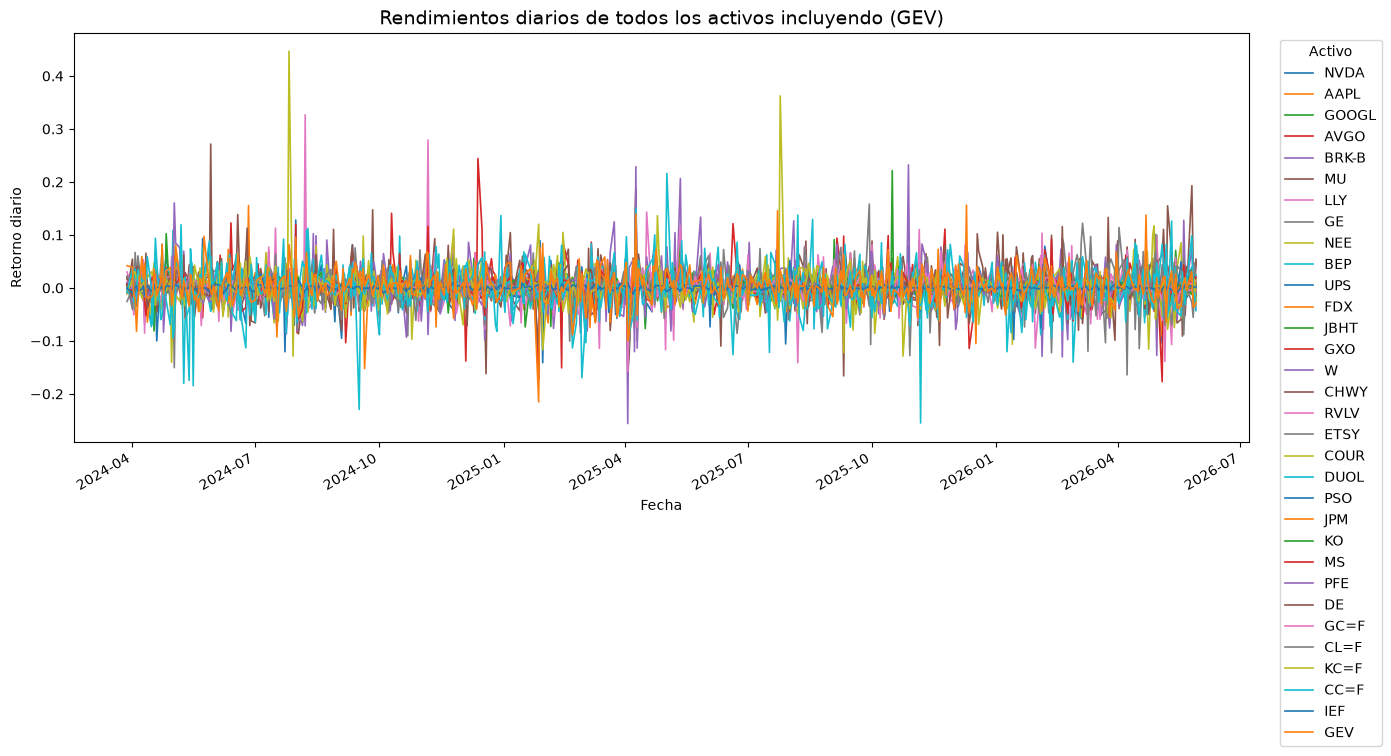

In [155]:
ax = sensitivity_daily_returns.plot.line(figsize=(14, 7), linewidth=1.2)
ax.set_title('Rendimientos diarios de todos los activos incluyendo (GEV)', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Retorno diario')
ax.legend(title='Activo', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [156]:
sensitivity_expected_returns = expected_returns.capm_return(
    sensitivity_price_matrix
)

sensitivity_covariance_matrix = (
    risk_models.sample_cov(
        sensitivity_price_matrix
    )
)

c:\Users\nicol\miniconda3\envs\portfolio_opt\Lib\site-packages\pypfopt\expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(


In [157]:
sensitivity_ef = EfficientFrontier(
    sensitivity_expected_returns,
    sensitivity_covariance_matrix,
    weight_bounds=(MIN_WEIGHT, MAX_WEIGHT)
)

sensitivity_ef.max_sharpe(
    risk_free_rate=RISK_FREE_RATE
)

sensitivity_weights = (
    sensitivity_ef.clean_weights()
)

In [158]:
sensitivity_performance = (
    sensitivity_ef.portfolio_performance(
        risk_free_rate=RISK_FREE_RATE
    )
)

In [159]:
sensitivity_weights_df = (
    pd.DataFrame.from_dict(
        sensitivity_weights,
        orient="index",
        columns=["weight"]
    )
    .reset_index(names="ticker")
)

sensitivity_weights_df = (
    sensitivity_weights_df
    .query("weight > 0")
    .sort_values("weight", ascending=False)
)

display(
    sensitivity_weights_df.style.format({
        "weight": "{:.2%}"
    })
)

,ticker,weight
13,GXO,11.17%
31,GEV,10.95%
14,W,10.05%
0,NVDA,7.76%
17,ETSY,7.15%
16,RVLV,6.83%
15,CHWY,5.88%
19,DUOL,5.79%
18,COUR,5.47%
5,MU,5.24%


In [160]:
sensitivity_summary = pd.DataFrame({
    "Scenario": [
        "Primary Universe",
        "Sensitivity Universe"
    ],
    "Expected Return": [
        max_sharpe_performance_constrained[0],
        sensitivity_performance[0]
    ],
    "Volatility": [
        max_sharpe_performance_constrained[1],
        sensitivity_performance[1]
    ],
    "Sharpe Ratio": [
        max_sharpe_performance_constrained[2],
        sensitivity_performance[2]
    ],
    "Selected Assets": [
        len(max_sharpe_weights_constrained_df),
        len(sensitivity_weights_df)
    ],
    "GEV Weight": [
        0,
        sensitivity_weights.get("GEV", 0)
    ]
})

display(
    sensitivity_summary.style.format({
        "Expected Return": "{:.2%}",
        "Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.2f}",
        "GEV Weight": "{:.2%}"
    })
)

,Scenario,Expected Return,Volatility,Sharpe Ratio,Selected Assets,GEV Weight
0,Primary Universe,27.61%,32.23%,0.73,19,0.00%
1,Sensitivity Universe,29.17%,31.63%,0.80,21,10.95%


In [161]:
print("Primary Universe")

display(
    max_sharpe_weights_constrained_df.style.format({
        "weight": "{:.2%}"
    })
)

print("Sensitivity Universe")

display(
    sensitivity_weights_df.style.format({
        "weight": "{:.2%}"
    })
)

Primary Universe


,ticker,weight
13,GXO,10.88%
14,W,10.47%
0,NVDA,9.00%
5,MU,7.92%
16,RVLV,7.66%
23,MS,7.46%
19,DUOL,6.44%
15,CHWY,6.17%
17,ETSY,6.15%
18,COUR,5.82%


Sensitivity Universe


,ticker,weight
13,GXO,11.17%
31,GEV,10.95%
14,W,10.05%
0,NVDA,7.76%
17,ETSY,7.15%
16,RVLV,6.83%
15,CHWY,5.88%
19,DUOL,5.79%
18,COUR,5.47%
5,MU,5.24%


### Discusión de resultados

El análisis de sensibilidad permite evaluar si la decisión de excluir General Electric Vernova durante la construcción del universo principal de inversión tiene un impacto significativo sobre la solución óptima obtenida.

Si las diferencias entre ambos escenarios son reducidas, puede concluirse que el modelo presenta un comportamiento robusto frente a la incorporación de un activo con un historial de precios limitado, validando así la decisión metodológica adoptada durante la preparación de los datos.

Por el contrario, si la incorporación de General Electric Vernova modifica de manera importante la composición del portafolio o las métricas de desempeño, ello indicaría que el modelo es sensible a la definición del universo de inversión. En ese caso, sería recomendable complementar el análisis con técnicas adicionales de validación o evaluar distintos horizontes temporales antes de implementar la estrategia de inversión.

## **Visualizaciones**

In [ ]:
from src.visualization import (
    plot_efficient_frontier,
    plot_allocation_bar,
    plot_sensitivity,
    plot_weights
)

In [163]:
efficient_volatility = []
efficient_returns = []

target_returns = np.linspace(
    expected_returns_vector.min(),
    expected_returns_vector.quantile(0.90),
    50
)

for target in target_returns:

    try:
        ef = EfficientFrontier(
            expected_returns_vector,
            covariance_matrix,
            weight_bounds=(MIN_WEIGHT, MAX_WEIGHT)
        )

        ef.efficient_return(target)

        ret, vol, _ = ef.portfolio_performance()

        efficient_returns.append(ret)
        efficient_volatility.append(vol)

    except Exception:
        continue

### Visualizacion de la frontera eficiente

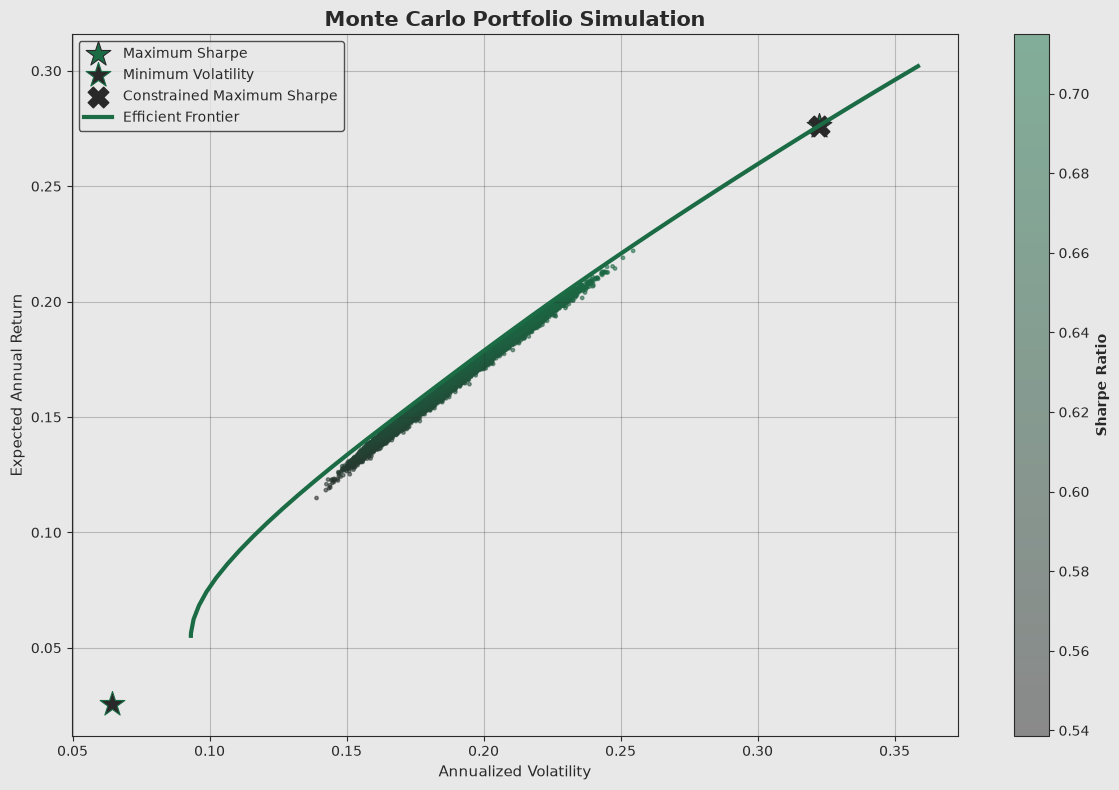

In [164]:
plot_efficient_frontier(
    simulation_results,
    max_sharpe_performance,
    min_volatility_performance,
    max_sharpe_performance_constrained,
    efficient_volatility,
    efficient_returns
)

### Visualizacion de los pesos distribuidos en las diferentes acciones

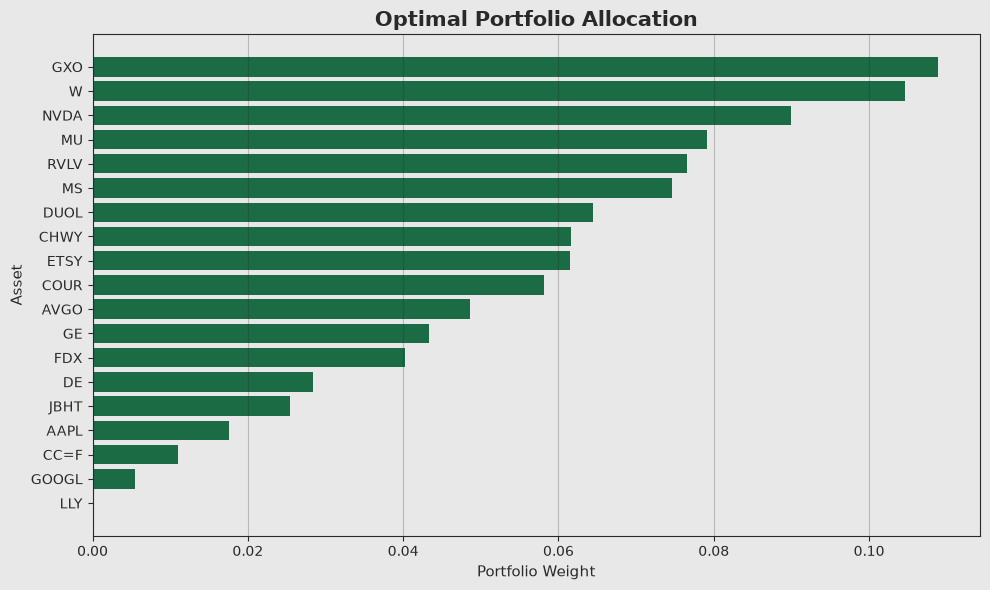

In [165]:
plot_weights(max_sharpe_weights_constrained_df)

### Distribucion segun la classe del activo

In [166]:
portfolio_asset_class = (
    max_sharpe_weights_constrained_df
    .merge(
        primary_universe[
            ["ticker", "asset_class"]
        ],
        on="ticker"
    )
    .groupby("asset_class", as_index=False)["weight"]
    .sum()
    .sort_values("weight", ascending=False)
)

portfolio_asset_class

,asset_class,weight
2,Equity - Growth,0.60151
3,Equity - Large Cap,0.28442
1,Equity - Established,0.10305
0,Commodity,0.01104


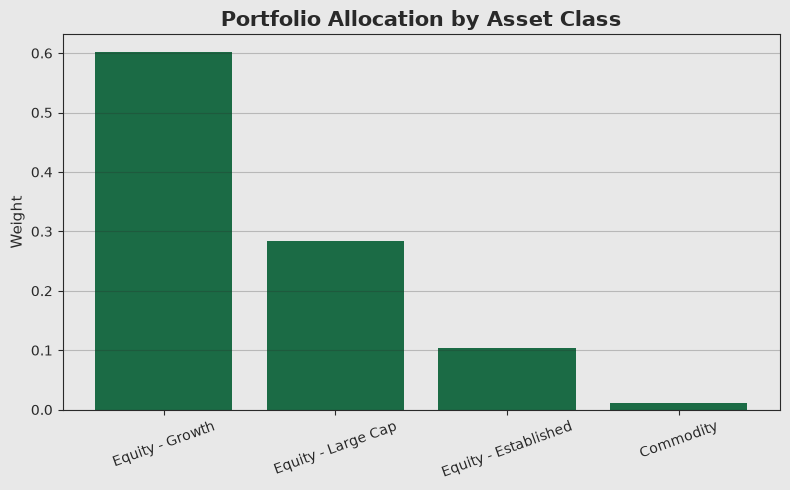

In [167]:
plot_allocation_bar(
    portfolio_asset_class, "asset_class", "weight",
    "Portfolio Allocation by Asset Class"
)

### Distribucion en base al sector

In [168]:
portfolio_sector = (
    max_sharpe_weights_constrained_df
    .merge(
        primary_universe[
            ["ticker", "sector"]
        ],
        on="ticker"
    )
    .groupby("sector", as_index=False)["weight"]
    .sum()
    .sort_values("weight", ascending=False)
)

portfolio_sector

,sector,weight
1,E-commerce,0.30442
9,Semiconductors,0.21776
7,Logistics,0.17454
2,EdTech,0.12255
3,Financial Services,0.07461
4,Industrials,0.04339
5,Industrials/Agriculture,0.02844
10,Technology Hardware,0.01751
0,Agrícola,0.01104
6,Internet & Media,0.00551


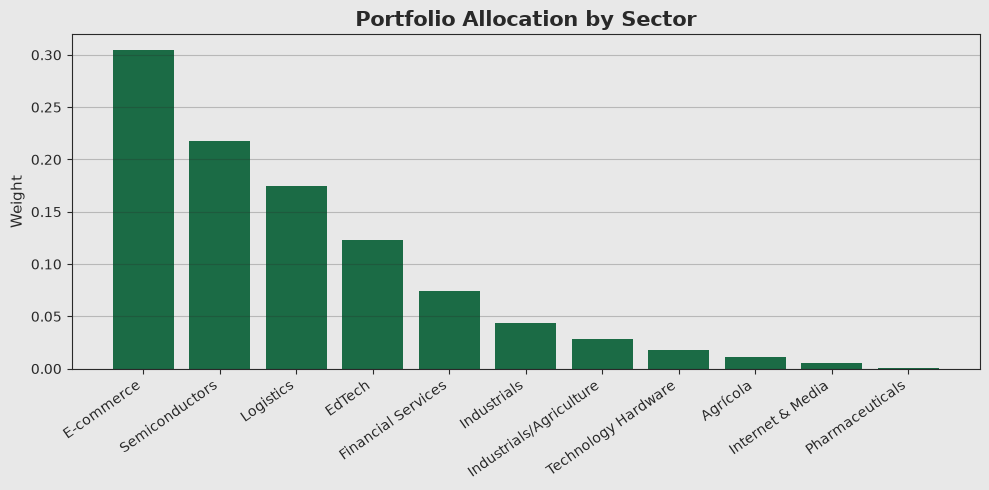

In [169]:
plot_allocation_bar(
    portfolio_sector, "sector", "weight",
    "Portfolio Allocation by Sector",
    rotation=35, ha="right", figsize=(10, 5)
)

### Comparacion de portafolios

Se compara el portafolio con restricciones con el analisis de sensibilidad

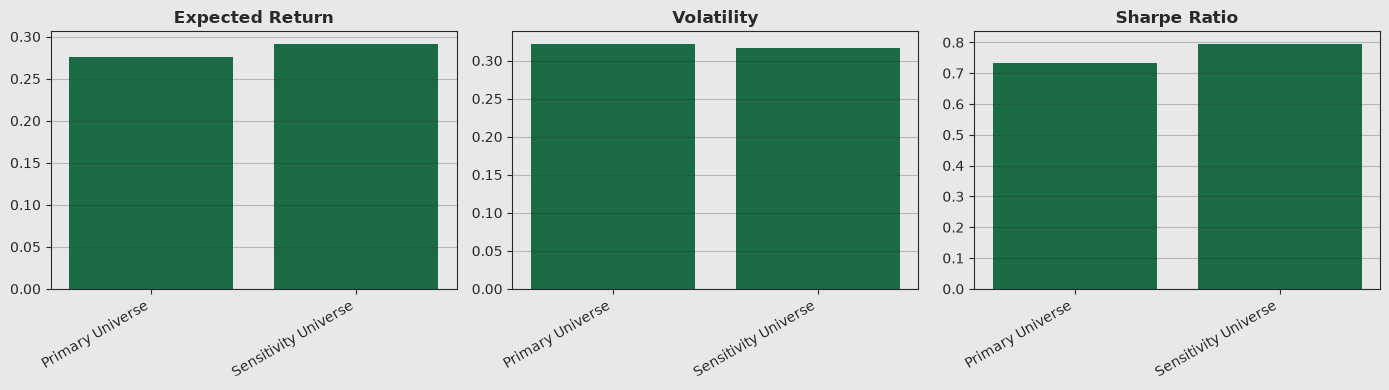

In [170]:
plot_sensitivity(sensitivity_summary)

## **Exportacion de entregables**